In [26]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

In [27]:
what_were_doing = {1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference)",
    5: "saving and loading a model",
    6: "putting it all together"
}

#We'll use the linear regression formula to make a straight line with known parameters -> *Y=a+bX* or *Y=wX+b*

In [28]:
#Creating a known parameters 

weight=0.7
bias=0.3

#Create

X=torch.arange(0,1,0.02).unsqueeze(dim=1)
y=weight*X+bias
X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [29]:
#Let's create a training and test set with each data

#Create a train 

train_split=int(0.8*len(X))

x_train=X[:train_split]
y_train=y[:train_split]
x_test=X[train_split:]
y_test=y[train_split:]

In [30]:
def plot_predictions(train_data=x_train,
                     train_label=y_train,
                     test_data=x_test,
                     test_label=y_test,
                     predictions=None):
    # plt.figure(figsize=(10,7))

    #Plot training data in blue

    plt.scatter(train_data,train_label,c="b",s=4,label="Training Data")

    #Plot the test data in green
    plt.scatter(test_data,test_label,c="g",s=4,label="Testing Data")

    #Now check the predictions 

    if predictions is not None:
        plt.scatter(test_data,predictions,c="r",s=4,label="Prediction")

    #Show the legend 
    plt.legend(prop={"size":14})
    plt.grid()


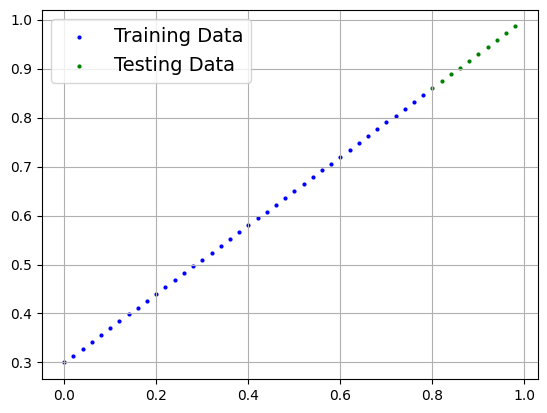

In [31]:
plot_predictions()

In [32]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)